# Predicción de casos de dengue en Bucaramanga con Deep Learning

Red neuronal multi-salida que predice la incidencia semanal de dengue en Bucaramanga (2020–2025) a partir de datos del SIVIGILA (datos.gov.co). Predice simultáneamente 10 categorías: total de casos, distribución por estrato socioeconómico, por sexo, gestantes y otros grupos vulnerables.

In [1]:
# ─── BLOQUE 1: LIBRERÍAS ───

import requests  # Librería para hacer peticiones HTTP a la API

import pandas as pd                     # Manejo de datos tabulares
import numpy as np                      # Operaciones numéricas
import matplotlib.pyplot as plt         # Gráficos y visualizaciones

from sklearn.preprocessing import StandardScaler     # Escalar datos a rango similar
from sklearn.linear_model import LinearRegression   # Modelo baseline (regresión lineal)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # MAE, MSE, R²

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Semillas fijas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("Librerías cargadas correctamente.")
print(f"TensorFlow {tf.__version__} | GPU disponible: {tf.config.list_physical_devices('GPU')}")

Librerías cargadas correctamente.
TensorFlow 2.20.0 | GPU disponible: []


In [2]:
# ─── BLOQUE 2: CARGA DE DATOS (vía API) ───

ID_DATASET = "qzc7-jbg3"
URL_BASE = f"https://www.datos.gov.co/resource/{ID_DATASET}.json"

TAMANO_BLOQUE = 50000       # Filas por petición
bloques = []                 # Almacena cada bloque descargado
offset = 0                   # Desde qué fila empezar

FILTRO = (
  "cod_dpto_r='68' AND cod_mun_r='1' "
  "AND fec_not between '2020-01-01T00:00:00' and '2025-12-31T23:59:59'"
)

while True:
  parametros = {
    "$limit": TAMANO_BLOQUE,
    "$offset": offset,
    "$where": FILTRO,
  }
  respuesta = requests.get(URL_BASE, params=parametros)
  respuesta.raise_for_status()           # Lanza error si la API falla
  datos_json = respuesta.json()          # JSON → lista de diccionarios

  if not datos_json:                     # Ya no hay más datos
    break

  bloques.append(pd.DataFrame(datos_json))
  print(f"Descargadas {len(datos_json)} filas (offset {offset})")
  offset += TAMANO_BLOQUE

df = pd.concat(bloques, ignore_index=True)  # Unir todos los bloques

df["fec_not"] = pd.to_datetime(df["fec_not"], errors="coerce")
df = df.dropna(subset=["fec_not"])  # Filtrar fechas inválidas

# Convertir columnas numéricas (la API las trae como texto)
columnas_numericas = ["estrato_", "gp_gestan", "gp_desplaz", "gp_indigen",
                       "gp_carcela", "gp_discapa", "gp_migrant", "a_o"]

for col in columnas_numericas:
  df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nRegistros cargados: {len(df):,}")
print(f"Rango de fechas: {df['fec_not'].min().date()} hasta {df['fec_not'].max().date()}")
print(f"Años presentes: {[int(a) for a in sorted(df['a_o'].dropna().unique())]}")

Descargadas 18969 filas (offset 0)

Registros cargados: 18,969
Rango de fechas: 2020-01-01 hasta 2025-09-02
Años presentes: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [3]:
# ─── BLOQUE 3: CONSTRUCCIÓN DE SERIES SEMANALES ───

# 3.1 Total de casos por semana
casos_total = df.set_index("fec_not").resample("W").size().rename("total")

# 3.2 Casos por estrato socioeconómico (1-6)
df_est = df[df["estrato_"] > 0].copy()
casos_estrato = (df_est.set_index("fec_not")
                 .groupby([pd.Grouper(freq="W"), "estrato_"])
                 .size()
                 .unstack(fill_value=0))  # Estratos como columnas separadas
for e in range(1, 7):
  if e not in casos_estrato.columns:
    casos_estrato[e] = 0  # Asegurar que existan estratos 1-6
casos_estrato = casos_estrato[[1,2,3,4,5,6]]
casos_estrato.columns = [f"estrato_{int(c)}" for c in casos_estrato.columns]

# 3.3 Casos por sexo
casos_sexo = (df.set_index("fec_not")
              .groupby([pd.Grouper(freq="W"), "sexo_"])
              .size()
              .unstack(fill_value=0))
casos_sexo.columns = [f"sexo_{c}" for c in casos_sexo.columns]

# 3.4 Gestantes
casos_gest = df[df["gp_gestan"] == 1].set_index("fec_not").resample("W").size().rename("gestantes")

# 3.5 Otros grupos vulnerables (desplazados, indígenas, carcelarios, discapacitados, migrantes)
es_vuln = (
    (df["gp_desplaz"] == 1) | (df["gp_indigen"] == 1) |
    (df["gp_carcela"] == 1) | (df["gp_discapa"] == 1) |
    (df["gp_migrant"] == 1)
)
casos_vuln = df[es_vuln].set_index("fec_not").resample("W").size().rename("otros_vulnerables")

# 3.6 Unir todo en un solo DataFrame
datos = pd.concat([casos_total, casos_estrato, casos_sexo, casos_gest, casos_vuln], axis=1).fillna(0)
datos = datos.astype(int)

SALIDAS = ["total"] + [f"estrato_{e}" for e in range(1,7)] + ["sexo_F", "sexo_M", "gestantes", "otros_vulnerables"]
datos = datos[SALIDAS]

print(f"Dataset semanal: {datos.shape[0]} semanas, {datos.shape[1]} columnas.")
print("\nResumen estadístico:")
print(datos.describe().round(1).T.to_string())

Dataset semanal: 297 semanas, 11 columnas.

Resumen estadístico:
                   count  mean   std  min  25%   50%   75%    max
total              297.0  63.9  89.9  0.0  8.0  22.0  85.0  475.0
estrato_1          297.0   8.2  11.8  0.0  1.0   3.0  11.0   69.0
estrato_2          297.0  21.9  28.2  0.0  3.0   8.0  32.0  124.0
estrato_3          297.0  21.6  31.5  0.0  2.0   7.0  29.0  165.0
estrato_4          297.0   8.0  13.8  0.0  0.0   2.0  10.0   79.0
estrato_5          297.0   1.0   2.2  0.0  0.0   0.0   1.0   17.0
estrato_6          297.0   0.6   1.4  0.0  0.0   0.0   1.0   13.0
sexo_F             297.0  31.3  45.6  0.0  3.0  10.0  41.0  243.0
sexo_M             297.0  32.6  44.6  0.0  4.0  12.0  45.0  232.0
gestantes          297.0   0.3   0.7  0.0  0.0   0.0   0.0    4.0
otros_vulnerables  297.0   1.1   1.8  0.0  0.0   0.0   1.0   10.0


In [4]:
# ─── BLOQUE 4: VARIABLES DE ENTRADA ───

# 4.1 Lags (rezagos) de 1 a 4 semanas del total de casos
# Permiten al modelo ver cómo las semanas pasadas influyen en la actual
datos["lag_1"] = datos["total"].shift(1)  # Casos de la semana pasada
datos["lag_2"] = datos["total"].shift(2)
datos["lag_3"] = datos["total"].shift(3)
datos["lag_4"] = datos["total"].shift(4)

# 4.2 Estacionalidad: seno y coseno de la semana del año
# Codificación continua para evitar el salto entre semana 52 y semana 1
semana_anio = datos.index.isocalendar().week.astype(int)
datos["semana_seno"] = np.sin(2 * np.pi * semana_anio / 52)
datos["semana_coseno"] = np.cos(2 * np.pi * semana_anio / 52)

datos = datos.dropna()  # Eliminar filas sin lags completos (primeras 4 semanas)

ENTRADAS = ["lag_1", "lag_2", "lag_3", "lag_4", "semana_seno", "semana_coseno"]

print(f"Dataset listo: {datos.shape[0]} semanas.")
print(f"Entradas: {ENTRADAS}")
print(f"Salidas: {SALIDAS}")

Dataset listo: 293 semanas.
Entradas: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'semana_seno', 'semana_coseno']
Salidas: ['total', 'estrato_1', 'estrato_2', 'estrato_3', 'estrato_4', 'estrato_5', 'estrato_6', 'sexo_F', 'sexo_M', 'gestantes', 'otros_vulnerables']


In [5]:
# ─── BLOQUE 5: DIVISIÓN TRAIN / TEST ───

n_test = int(len(datos) * 0.2)  # 80% train, 20% test
train = datos.iloc[:-n_test]    # Datos pasados para entrenar
test  = datos.iloc[-n_test:]    # Datos futuros para evaluar

X_train = train[ENTRADAS].values  # Entradas de entrenamiento
X_test  = test[ENTRADAS].values   # Entradas de prueba
Y_train = train[SALIDAS].values  # Salidas reales (train)
Y_test  = test[SALIDAS].values   # Salidas reales (test)

print(f"Train: {len(X_train)} semanas ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(X_test)} semanas ({test.index[0].date()} → {test.index[-1].date()})")

Train: 235 semanas (2020-02-02 → 2024-07-28)
Test:  58 semanas (2024-08-04 → 2025-09-07)


In [6]:
# ─── BLOQUE 6: ESCALADO ───

# Estandarizar datos (media=0, desviación=1) ayuda a la red neuronal a aprender mejor
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)  # Calcula parámetros y transforma
X_test_s  = scaler_X.transform(X_test)        # Misma transformación en test

# También escalamos las salidas (cada una tiene escala distinta)
scaler_Y = StandardScaler()
Y_train_s = scaler_Y.fit_transform(Y_train)
Y_test_s  = scaler_Y.transform(Y_test)

print("Datos escalados y listos para el modelo.")

Datos escalados y listos para el modelo.


In [7]:
# ─── BLOQUE 7: MODELO BASELINE — REGRESIÓN LINEAL ───

# Línea base para comparar con la red neuronal
baseline = LinearRegression()
baseline.fit(X_train_s, Y_train_s)

pred_baseline_s = baseline.predict(X_test_s)
pred_baseline = scaler_Y.inverse_transform(pred_baseline_s)  # Desescalar a valores originales

print("=== Modelo BASELINE: Regresión Lineal ===\n")
for i, nombre in enumerate(SALIDAS):
  mae = mean_absolute_error(Y_test[:, i], pred_baseline[:, i])  # Error Promedio Absoluto
  r2  = r2_score(Y_test[:, i], pred_baseline[:, i])             # Precisión del modelo
  print(f"{nombre:20s} | Error Promedio (MAE): {mae:6.2f} casos | Precisión (R²): {r2:6.3f}")

=== Modelo BASELINE: Regresión Lineal ===

total                | Error Promedio (MAE):  20.64 casos | Precisión (R²):  0.751
estrato_1            | Error Promedio (MAE):   4.45 casos | Precisión (R²):  0.425
estrato_2            | Error Promedio (MAE):   6.48 casos | Precisión (R²):  0.808
estrato_3            | Error Promedio (MAE):   7.88 casos | Precisión (R²):  0.789
estrato_4            | Error Promedio (MAE):   5.18 casos | Precisión (R²):  0.185
estrato_5            | Error Promedio (MAE):   1.50 casos | Precisión (R²): -1.937
estrato_6            | Error Promedio (MAE):   0.82 casos | Precisión (R²):  0.196
sexo_F               | Error Promedio (MAE):  11.52 casos | Precisión (R²):  0.697
sexo_M               | Error Promedio (MAE):  10.61 casos | Precisión (R²):  0.751
gestantes            | Error Promedio (MAE):   0.49 casos | Precisión (R²):  0.059
otros_vulnerables    | Error Promedio (MAE):   1.05 casos | Precisión (R²):  0.141


In [8]:
# ─── BLOQUE 8: RED NEURONAL MULTI-SALIDA ───

modelo = Sequential([
  Dense(32, activation="relu", input_shape=(len(ENTRADAS),), kernel_regularizer=l2(0.0005)),
  Dropout(0.2),  # Apaga 20% de neuronas al azar para evitar sobreajuste
  Dense(24, activation="relu", kernel_regularizer=l2(0.0005)),
  Dense(len(SALIDAS), activation="linear")  # 11 salidas (una por categoría)
])

modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo.summary()

# EarlyStopping: detiene el entrenamiento si la pérdida de validación deja de mejorar
early_stop = EarlyStopping(patience=30, restore_best_weights=True)

historial = modelo.fit(
  X_train_s, Y_train_s,
  epochs=500,
  batch_size=16,
  validation_data=(X_test_s, Y_test_s),
  callbacks=[early_stop],
  verbose=1
)

pred_red_s = modelo.predict(X_test_s, verbose=0)        # Predicciones en escala
pred_red_train_s = modelo.predict(X_train_s, verbose=0)  # Predicciones en train

pred_red = scaler_Y.inverse_transform(pred_red_s)              # Desescalar test
pred_red_train = scaler_Y.inverse_transform(pred_red_train_s)  # Desescalar train

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │           275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291 (5.04 KB)

 Trainable params: 1,291 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.1797 - mae: 0.6480 - val_loss: 0.7003 - val_mae: 0.5159
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0198 - mae: 0.6066 - val_loss: 0.5927 - val_mae: 0.4840
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9376 - mae: 0.5720 - val_loss: 0.5310 - val_mae: 0.4650
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8230 - mae: 0.5338 - val_loss: 0.4825 - val_mae: 0.4499
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7396 - mae: 0.4976 - val_loss: 0.4329 - val_mae: 0.4331
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6679 - mae: 0.4572 - val_loss: 0.3850 - val_mae: 0.4138
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5640 - mae: 0.4128 - val_loss: 0.3499 - val_mae: 0.4009
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4554 - mae: 0.3695 - val_loss: 0.3303 - val_mae: 0.3951
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.35

In [9]:
# ─── BLOQUE 9: MÉTRICAS POR SALIDA ───

print("=== Evaluación de la RED NEURONAL ===\n")
metricas = []
for i, nombre in enumerate(SALIDAS):
  mae = mean_absolute_error(Y_test[:, i], pred_red[:, i])     # Error Promedio Absoluto
  rmse = np.sqrt(mean_squared_error(Y_test[:, i], pred_red[:, i]))  # Error Típico (penaliza errores grandes)
  r2  = r2_score(Y_test[:, i], pred_red[:, i])               # Precisión del modelo
  metricas.append({"salida": nombre, "mae": mae, "rmse": rmse, "r2": r2})
  print(f"{nombre:20s} | Error Promedio (MAE): {mae:6.2f} | Error Típico (RMSE): {rmse:6.2f} | Precisión (R²): {r2:6.3f}")

df_metricas = pd.DataFrame(metricas)

=== Evaluación de la RED NEURONAL ===

total                | Error Promedio (MAE):  17.81 | Error Típico (RMSE):  22.65 | Precisión (R²):  0.839
estrato_1            | Error Promedio (MAE):   4.10 | Error Típico (RMSE):   5.23 | Precisión (R²):  0.553
estrato_2            | Error Promedio (MAE):   9.15 | Error Típico (RMSE):  11.47 | Precisión (R²):  0.656
estrato_3            | Error Promedio (MAE):   6.54 | Error Típico (RMSE):   8.26 | Precisión (R²):  0.860
estrato_4            | Error Promedio (MAE):   4.50 | Error Típico (RMSE):   6.32 | Precisión (R²):  0.402
estrato_5            | Error Promedio (MAE):   1.27 | Error Típico (RMSE):   1.61 | Precisión (R²): -0.732
estrato_6            | Error Promedio (MAE):   0.80 | Error Típico (RMSE):   0.95 | Precisión (R²):  0.218
sexo_F               | Error Promedio (MAE):  11.26 | Error Típico (RMSE):  13.93 | Precisión (R²):  0.760
sexo_M               | Error Promedio (MAE):   9.40 | Error Típico (RMSE):  12.48 | Precisión (R²):  0.81

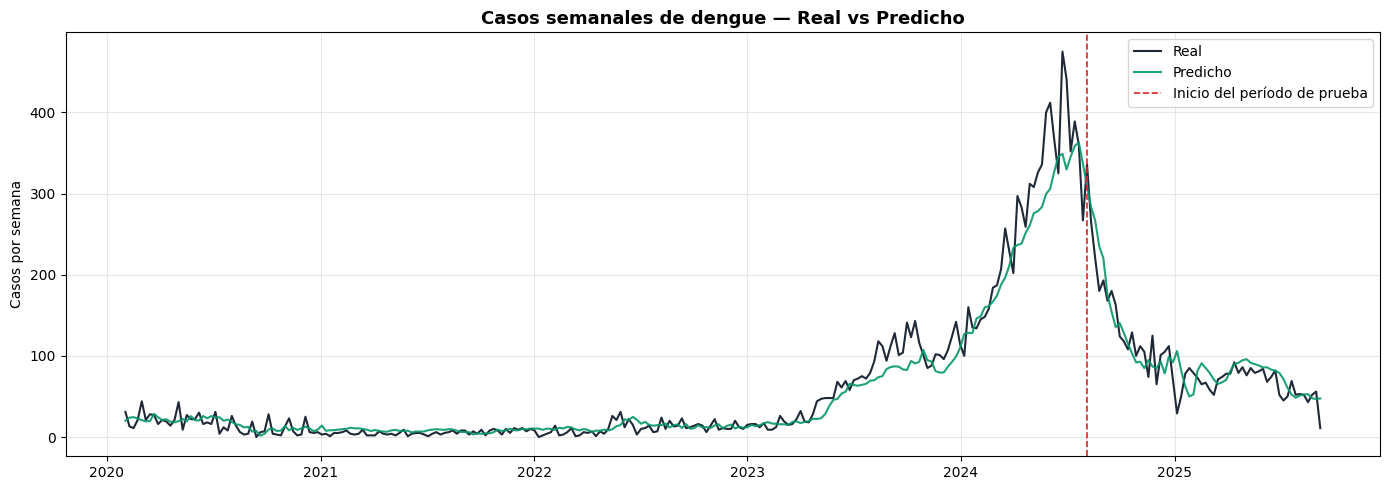

In [10]:
# ─── BLOQUE 10: GRÁFICA 1 — SERIE TEMPORAL TOTAL ───

serie_total_real = datos["total"].values
serie_total_pred = np.empty(len(datos))
serie_total_pred[:] = np.nan
serie_total_pred[:len(train)] = pred_red_train[:, 0]  # Predicciones en train
serie_total_pred[len(train):] = pred_red[:, 0]        # Predicciones en test

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(datos.index, serie_total_real, label="Real", color="#1f2937", linewidth=1.5)
ax.plot(datos.index, serie_total_pred, label="Predicho", color="#059669", linewidth=1.5, alpha=0.9)
ax.axvline(test.index[0], color="#dc2626", linestyle="--", linewidth=1.2, label="Inicio del período de prueba")
ax.set_title("Casos semanales de dengue — Real vs Predicho", fontsize=13, fontweight="bold")
ax.set_ylabel("Casos por semana")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("grafica_1_serie_total.png", dpi=150)
plt.show()

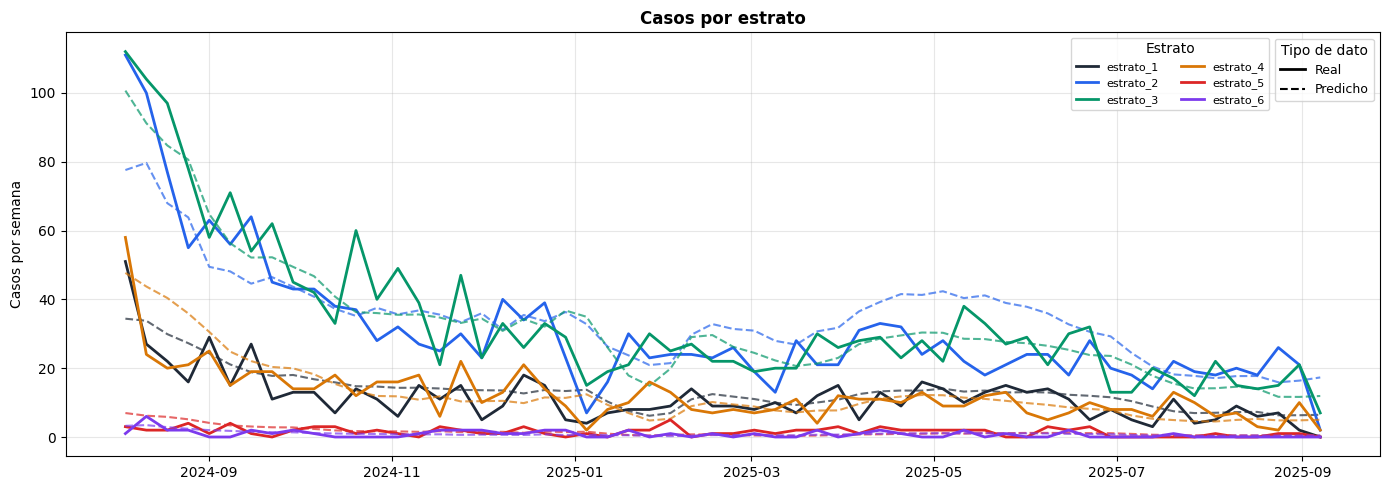

In [11]:
# ─── BLOQUE 11: GRÁFICA 2 — ESTRATOS SOCIOECONÓMICOS (REAL VS PREDICHO) ───

# Real = línea sólida, Predicho = línea punteada
colores_estrato = ["#1f2937", "#2563eb", "#059669", "#d97706", "#dc2626", "#7c3aed"]
estratos = [f"estrato_{e}" for e in range(1, 7)]

fig, ax = plt.subplots(figsize=(14, 5))
for i, nombre in enumerate(estratos):
  idx = SALIDAS.index(nombre)
  ax.plot(test.index, Y_test[:, idx], color=colores_estrato[i], linewidth=2, label=nombre)
  ax.plot(test.index, pred_red[:, idx], color=colores_estrato[i], linewidth=1.5, linestyle="--", alpha=0.7)

# Leyenda 1: qué color es cada estrato
leyenda_colores = ax.legend(loc="upper right", bbox_to_anchor=(0.92, 1), fontsize=8, ncol=2, title="Estrato")
ax.add_artist(leyenda_colores)  # para que no la borre la segunda leyenda

# Leyenda 2: qué significa cada estilo de línea (independiente del color)
from matplotlib.lines import Line2D
lineas_estilo = [
  Line2D([0], [0], color="black", linewidth=2, linestyle="-", label="Real"),
  Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="Predicho"),
]
ax.legend(handles=lineas_estilo, loc="upper right", bbox_to_anchor=(1, 1), fontsize=9, title="Tipo de dato")

ax.set_title("Casos por estrato", fontsize=12, fontweight="bold")
ax.set_ylabel("Casos por semana")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("grafica_2_estratos.png", dpi=150)
plt.show()

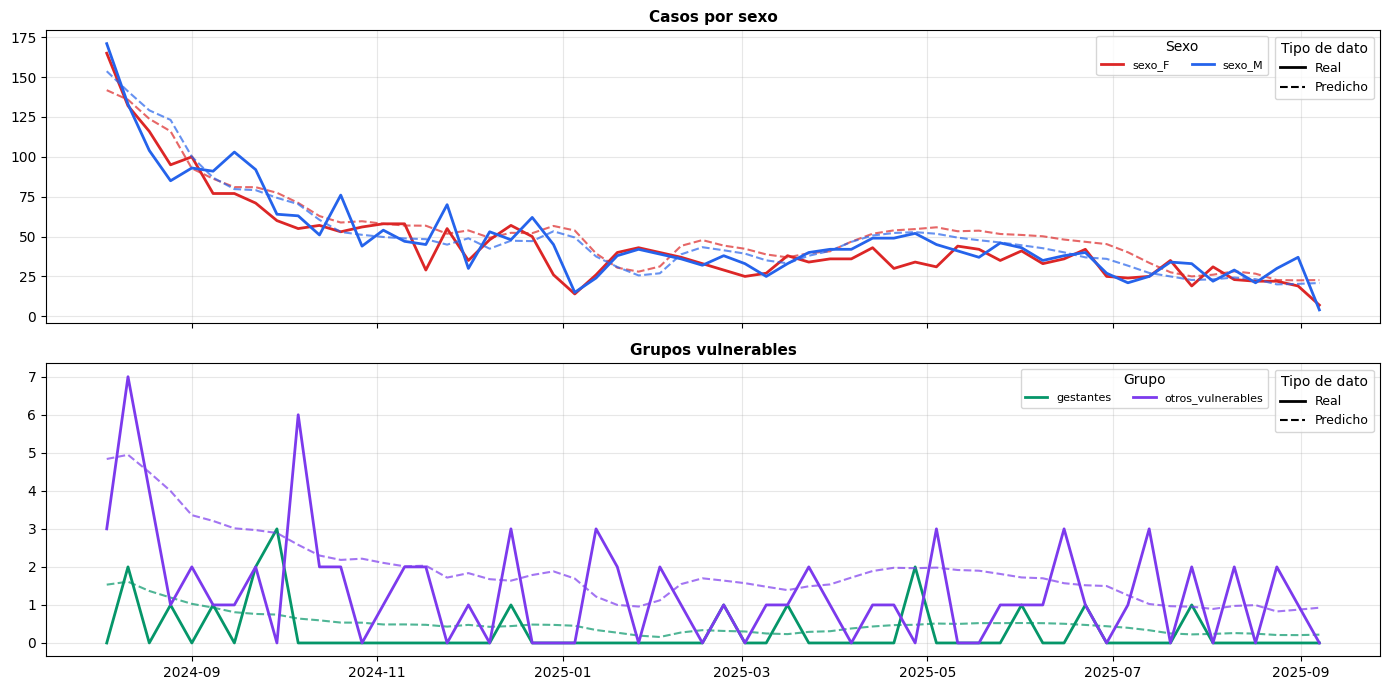

In [12]:
# ─── BLOQUE 12: GRÁFICA 3 — SEXO Y GRUPOS VULNERABLES (REAL VS PREDICHO) ───

# Real = línea sólida, Predicho = punteada
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

from matplotlib.lines import Line2D

# Leyenda de estilos (común para ambos subplots)
lineas_estilo = [
  Line2D([0], [0], color="black", linewidth=2, linestyle="-", label="Real"),
  Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="Predicho"),
]

# --- Subplot 1: Sexo ---
colores_sexo = ["#dc2626", "#2563eb"]
for i, nombre in enumerate(["sexo_F", "sexo_M"]):
  idx = SALIDAS.index(nombre)
  axes[0].plot(test.index, Y_test[:, idx], color=colores_sexo[i], linewidth=2, label=nombre)
  axes[0].plot(test.index, pred_red[:, idx], color=colores_sexo[i], linewidth=1.5, linestyle="--", alpha=0.7)

axes[0].set_title("Casos por sexo", fontsize=11, fontweight="bold")
# Leyenda 1: colores
leyenda_sexo = axes[0].legend(loc="upper right", bbox_to_anchor=(0.92, 1), fontsize=8, ncol=2, title="Sexo")
axes[0].add_artist(leyenda_sexo)
# Leyenda 2: estilos
axes[0].legend(handles=lineas_estilo, loc="upper right", bbox_to_anchor=(1, 1), fontsize=9, title="Tipo de dato")
axes[0].grid(True, alpha=0.3)

# --- Subplot 2: Grupos vulnerables ---
colores_vuln = ["#059669", "#7c3aed"]
for i, nombre in enumerate(["gestantes", "otros_vulnerables"]):
  idx = SALIDAS.index(nombre)
  axes[1].plot(test.index, Y_test[:, idx], color=colores_vuln[i], linewidth=2, label=nombre)
  axes[1].plot(test.index, pred_red[:, idx], color=colores_vuln[i], linewidth=1.5, linestyle="--", alpha=0.7)

axes[1].set_title("Grupos vulnerables", fontsize=11, fontweight="bold")
# Leyenda 1: colores
leyenda_vuln = axes[1].legend(loc="upper right", bbox_to_anchor=(0.92, 1), fontsize=8, ncol=2, title="Grupo")
axes[1].add_artist(leyenda_vuln)
# Leyenda 2: estilos
axes[1].legend(handles=lineas_estilo, loc="upper right", bbox_to_anchor=(1, 1), fontsize=9, title="Tipo de dato")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("grafica_3_sexo_vulnerables.png", dpi=150)
plt.show()


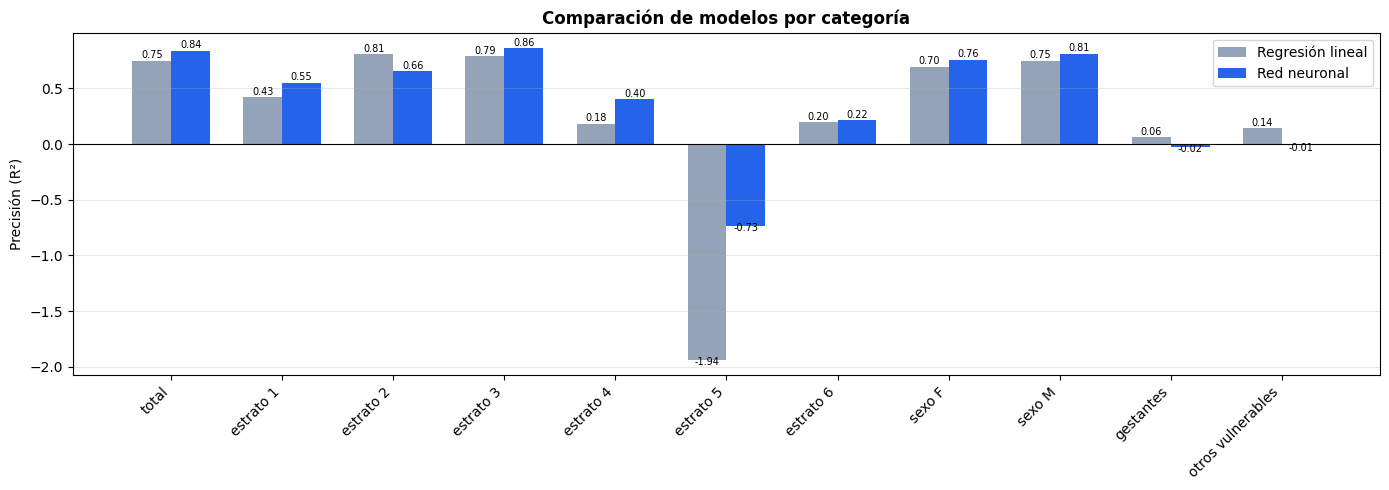

In [13]:
# ─── BLOQUE 13: GRÁFICA 4 — ¿QUIÉN PREDICE MEJOR, EL MODELO SIMPLE O LA RED? ───

# R² = 1 es predicción perfecta, R² = 0 es como adivinar el promedio
r2_baseline = [r2_score(Y_test[:, i], pred_baseline[:, i]) for i in range(len(SALIDAS))]
r2_red = [r2_score(Y_test[:, i], pred_red[:, i]) for i in range(len(SALIDAS))]

x = np.arange(len(SALIDAS))
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - ancho/2, r2_baseline, ancho, label="Regresión lineal", color="#94a3b8")
b2 = ax.bar(x + ancho/2, r2_red, ancho, label="Red neuronal", color="#2563eb")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in SALIDAS], rotation=45, ha="right")
ax.set_ylabel("Precisión (R²)")
ax.set_title("Comparación de modelos por categoría", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for barras in [b1, b2]:
  for b in barras:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+(0.02 if b.get_height()>=0 else -0.05),
            f"{b.get_height():.2f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("grafica_4_comparacion_modelos.png", dpi=150)
plt.show()

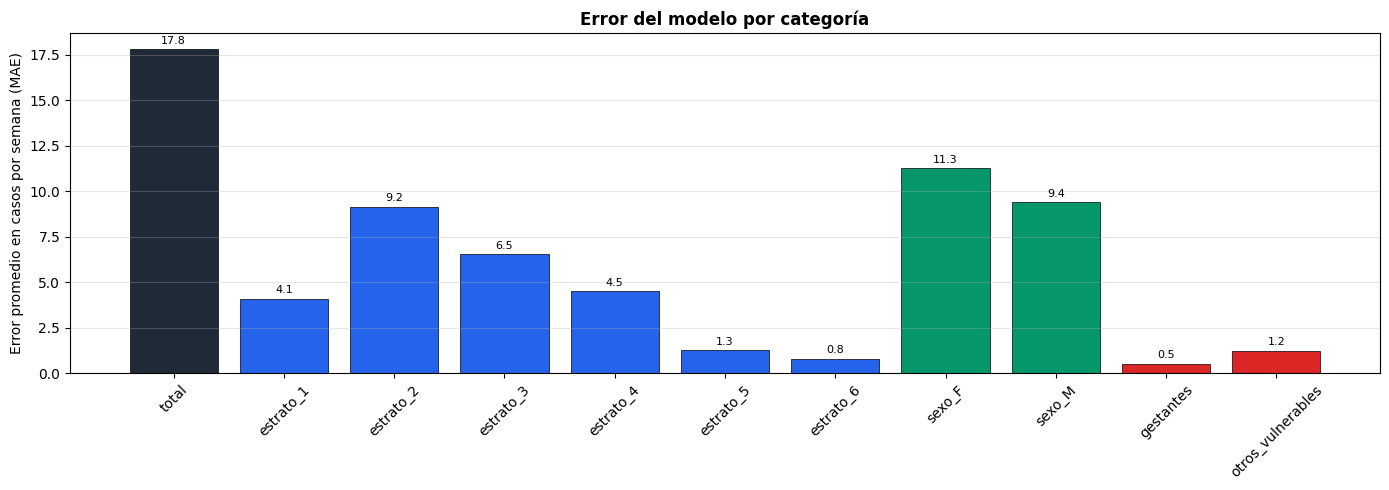

In [14]:
# ─── BLOQUE 14: GRÁFICA 5 — ¿EN CUÁNTOS CASOS SE EQUIVOCA EL MODELO? ───

# MAE: error promedio en casos por semana (qué tan lejos falla el modelo)
fig, ax = plt.subplots(figsize=(14, 5))
colores_bar = ["#1f2937"] + ["#2563eb"]*6 + ["#059669", "#059669", "#dc2626", "#dc2626"]

barras = ax.bar(df_metricas["salida"], df_metricas["mae"], color=colores_bar, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Error promedio en casos por semana (MAE)")
ax.set_title("Error del modelo por categoría", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
for b in barras:
  ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("grafica_5_error_categoria.png", dpi=150)
plt.show()

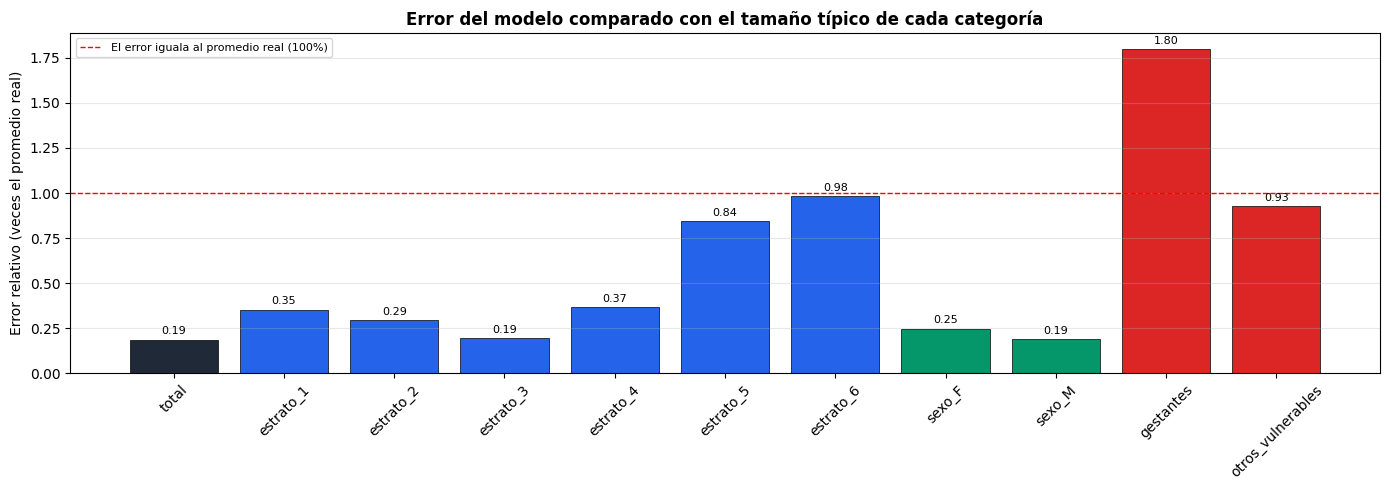

In [15]:
# ─── BLOQUE 14b: ¿EL MODELO FALLA IGUAL EN TODAS LAS CATEGORÍAS O SOLO EN LAS CHICAS? ───

# MAE dividido por el promedio real: >1 significa que el error supera al valor típico
promedios_reales = Y_test.mean(axis=0)
error_relativo = df_metricas["mae"].values / promedios_reales

fig, ax = plt.subplots(figsize=(14, 5))
barras = ax.bar(df_metricas["salida"], error_relativo, color=colores_bar, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Error relativo (veces el promedio real)")
ax.set_title("Error del modelo comparado con el tamaño típico de cada categoría", fontsize=12, fontweight="bold")
ax.axhline(1, color="red", linestyle="--", linewidth=1, label="El error iguala al promedio real (100%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
for b in barras:
  ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03, f"{b.get_height():.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("grafica_5b_error_relativo.png", dpi=150)
plt.show()